/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


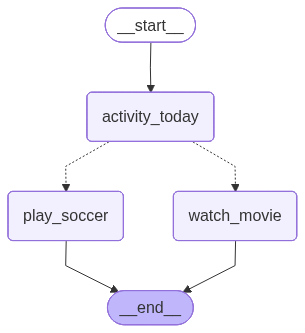

Activity today node has been called
Current State: {'graph_info': 'Today'}
Inside random activity decider
Soccer node has been called

FINAL RESULT
{'graph_info': 'Today -> Planning activities for today -> Playing soccer'}

STREAMING EXECUTION
Activity today node has been called
Current State: {'graph_info': 'Streaming Example'}
Inside random activity decider
{'activity_today': {'graph_info': 'Streaming Example -> Planning activities for today'}}
Watch movie node has been called
{'watch_movie': {'graph_info': 'Streaming Example -> Planning activities for today -> Watching movie'}}


In [3]:
"""
=============================================================
FILE 1 — INTRODUCTION TO LANGGRAPH WORKFLOWS
=============================================================

CONCEPTS TAUGHT:
-----------------
1. What is LangGraph?
2. What is State?
3. State as shared memory between nodes
4. Nodes as Python functions
5. START and END nodes
6. Edges and graph flow
7. Conditional routing
8. Graph compilation
9. invoke()
10. stream()
11. Immutable state updates
12. Visualization

KEY IDEA:
---------
LangGraph is a stateful workflow engine.
Each node reads and updates a shared state.

"""

# TypedDict helps us define the structure of our graph state
from typing_extensions import TypedDict


# =============================================================
# STEP 1 — DEFINE GRAPH STATE
# =============================================================
# State is the shared memory of the graph.
# Every node receives the current state.
# Every node returns updates to the state.

class State(TypedDict):
    graph_info: str

# =============================================================
# STEP 2 — DEFINE NODES
# =============================================================
# Nodes are simply Python functions.
#
# IMPORTANT:
# - First parameter must be state
# - Nodes READ from state
# - Nodes RETURN state updates
#
# We generally avoid mutating state directly.
# Instead, we return updates.


def activity_today(state: State):
    """
    This node updates the state
    and adds activity planning information.
    """

    print("Activity today node has been called")
    print("Current State:", state)

    return {
        "graph_info": state["graph_info"] + " -> Planning activities for today"
    }

def play_soccer(state: State):
    """
    Node representing soccer activity.
    """

    print("Soccer node has been called")

    return {
        "graph_info": state["graph_info"] + " -> Playing soccer"
    }



def watch_movie(state: State):
    """
    Node representing movie activity.
    """

    print("Watch movie node has been called")

    return {
        "graph_info": state["graph_info"] + " -> Watching movie"
    }

# =============================================================
# STEP 3 — CONDITIONAL ROUTING
# =============================================================
# LangGraph supports dynamic routing.
#
# A routing function decides:
# "Which node should execute next?"
#
# The function returns the NEXT NODE NAME.

import random
from typing import Literal

def random_activity_decider(
    state: State,
) -> Literal["play_soccer", "watch_movie"]:
    """
    Randomly choose the next activity.

    Literal[] defines the possible next nodes.
    """

    print("Inside random activity decider")

    if random.random() > 0.5:
        return "play_soccer"
    else:
        return "watch_movie"


# =============================================================
# STEP 4 — BUILD THE GRAPH
# =============================================================
# StateGraph is the main LangGraph class.
#
# START = graph entry point
# END   = graph termination point

from langgraph.graph import StateGraph, START, END


# Create graph object
workflow = StateGraph(State)


# =============================================================
# STEP 5 — ADD NODES
# =============================================================
workflow.add_node("activity_today", activity_today)
workflow.add_node("play_soccer", play_soccer)
workflow.add_node("watch_movie", watch_movie)

# =============================================================
# STEP 6 — ADD EDGES
# =============================================================
# Edges define graph execution flow.

workflow.add_edge(START, "activity_today")

# Conditional edge means:
# Next node is decided dynamically.
workflow.add_conditional_edges(
    "activity_today",
    random_activity_decider,
)

workflow.add_edge("play_soccer", END)
workflow.add_edge("watch_movie", END)

# =============================================================
# STEP 7 — COMPILE GRAPH
# =============================================================
# compile() converts the graph definition
# into an executable application.

app = workflow.compile()


# =============================================================
# STEP 8 — VISUALIZE GRAPH
# =============================================================
from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))

# =============================================================
# STEP 9 — INVOKE GRAPH
# =============================================================
# invoke() runs the graph once.

result = app.invoke(
    {
        "graph_info": "Today"
    }
)

print("\nFINAL RESULT")
print(result)

# =============================================================
# STEP 10 — STREAM GRAPH EXECUTION
# =============================================================
# stream() allows us to observe graph execution step-by-step.
#
# This is VERY important for real agents.

print("\nSTREAMING EXECUTION")

for event in app.stream(
    {
        "graph_info": "Streaming Example"
    }
):
    print(event)

